In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input

In [3]:
train_df = pd.read_csv('Google_Stock_Price_Train.csv')
test_df = pd.read_csv('Google_Stock_Price_Test.csv')

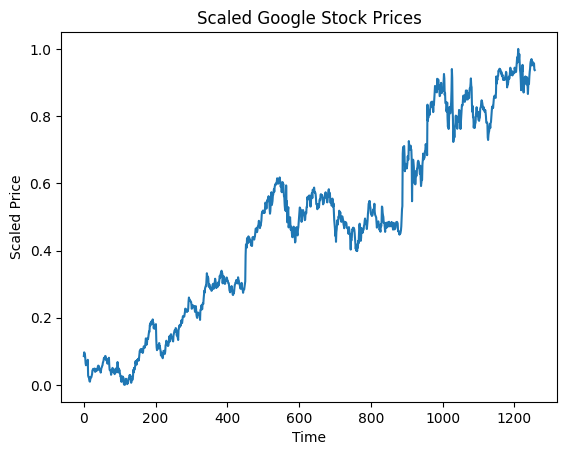

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[['Open']].values)

plt.plot(train_scaled)
plt.title("Scaled Google Stock Prices")
plt.xlabel("Time")
plt.ylabel("Scaled Price")
plt.show()

In [5]:
time_step = 120
x_train, y_train = [], []

for i in range(time_step, train_scaled.shape[0]):
    x_train.append(train_scaled[i-time_step:i, 0])
    y_train.append(train_scaled[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [6]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [7]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(units=50))
model.add(Dense(1))

c:\Users\nkolh\OneDrive\Desktop\sem 8 codes\DL\clean_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(100, activation='tanh', return_sequences=True), Dropout(0.3),
    LSTM(100, activation='tanh'), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 120, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(x_train, y_train, epochs=200, batch_size=50, validation_split=0.05)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 0.1406 - val_loss: 0.1507
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - loss: 0.0561 - val_loss: 0.0282
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0469 - val_loss: 0.0419
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0463 - val_loss: 0.0334
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - loss: 0.0408 - val_loss: 0.0283
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0416 - val_loss: 0.0231
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0422 - val_loss: 0.0406
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.0397 - val_loss: 0.0282
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.0404 - val_loss: 0.0339
Epoch 10/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0403 - val_loss: 0.0321
Epoch 11/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0408 - val_loss: 0.0658
Epoch 12/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3

In [10]:
data = pd.concat((train_df['Open'], test_df['Open']), axis=0)
test_input = data[len(data) - len(test_df) - time_step:].values.reshape(-1, 1)

test_scaled = scaler.transform(test_input)

In [11]:
x_test = []
for i in range(time_step, test_scaled.shape[0]):
    x_test.append(test_scaled[i-time_step:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [14]:
X_test = []

for i in range(60, len(test_input)):
    X_test.append(test_input[i-60:i, 0])

X_test = np.array(X_test)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [15]:
y_pred = model.predict(x_test)
y_pred = scaler.inverse_transform(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step


In [16]:
y_test = test_df['Open'].values
output = model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 806.5699


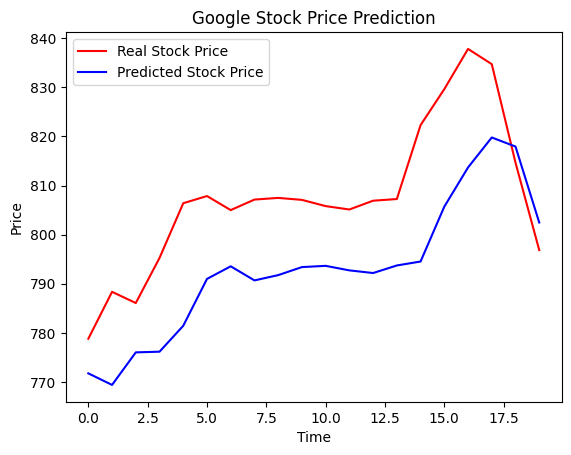

In [17]:
plt.plot(y_test, color='red', label='Real Stock Price')
plt.plot(y_pred, color='blue', label='Predicted Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()